In [3]:
import pandas as pd
import numpy as np

dataset = pd.read_csv('/kaggle/input/india-air-quality-data/data.csv', encoding = 'latin1')

print('\nFirst 5 rows:\n', dataset.head())
print('\nColumns:\n', dataset.columns)
print('\nShape:\n', dataset.shape)



First 5 rows:
   stn_code       sampling_date           state   location agency  \
0    150.0  February - M021990  Andhra Pradesh  Hyderabad    NaN   
1    151.0  February - M021990  Andhra Pradesh  Hyderabad    NaN   
2    152.0  February - M021990  Andhra Pradesh  Hyderabad    NaN   
3    150.0     March - M031990  Andhra Pradesh  Hyderabad    NaN   
4    151.0     March - M031990  Andhra Pradesh  Hyderabad    NaN   

                                 type  so2   no2  rspm  spm  \
0  Residential, Rural and other Areas  4.8  17.4   NaN  NaN   
1                     Industrial Area  3.1   7.0   NaN  NaN   
2  Residential, Rural and other Areas  6.2  28.5   NaN  NaN   
3  Residential, Rural and other Areas  6.3  14.7   NaN  NaN   
4                     Industrial Area  4.7   7.5   NaN  NaN   

  location_monitoring_station  pm2_5        date  
0                         NaN    NaN  1990-02-01  
1                         NaN    NaN  1990-02-01  
2                         NaN    NaN  1990-

/tmp/ipykernel_55/4158554930.py:4: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  dataset = pd.read_csv('/kaggle/input/india-air-quality-data/data.csv', encoding = 'latin1')


In [5]:
#Step 1
x = dataset['no2']
x

# transformation function
def transform(x, r):
    a_r = 0.5*(r%7)
    b_r = 0.5*(r%5+1)
    z = x+a_r*np.sin(b_r*x)

    return z

roll_number = 102317003

z = transform(x,roll_number)

print(z)

0         16.799721
1          9.476518
2         29.590412
3         12.443613
4          9.125720
            ...    
435737    48.734086
435738    44.051335
435739          NaN
435740          NaN
435741          NaN
Name: no2, Length: 435742, dtype: float64


In [6]:
# Step 2
from keras.models import Sequential
from keras.layers import Dense
from numpy.random import randn
from numpy.random import randint
from numpy import ones, zeros

z_clean = z.dropna().values
z_clean = z_clean.reshape(len(z_clean), 1)

def generate_real_samples(n):
    idx = randint(0, z_clean.shape[0], n)
    X = z_clean[idx]
    y = ones((n, 1))
    return X, y

def generate_fake_samples(generator, n):
    error = randn(n, 1)
    X = generator.predict(error, verbose=0)
    y = zeros((n, 1))
    return X, y

def define_discriminator():
    model = Sequential()
    model.add(Dense(16, activation='relu', input_dim=1))
    model.add(Dense(1, activation='sigmoid'))
    model.compile(loss='binary_crossentropy', optimizer='adam')
    return model

def define_generator():
    model = Sequential()
    model.add(Dense(16, activation='relu', input_dim=1))
    model.add(Dense(1))
    return model

def define_gan(generator, discriminator):
    discriminator.trainable = False
    model = Sequential()
    model.add(generator)
    model.add(discriminator)
    model.compile(loss='binary_crossentropy', optimizer='adam')
    return model

discriminator = define_discriminator()
generator = define_generator()
gan_model = define_gan(generator, discriminator)

epochs = 1000
batch = 64
half_batch = batch // 2

for i in range(epochs):
    X_real, y_real = generate_real_samples(half_batch)
    discriminator.train_on_batch(X_real, y_real)

    X_fake, y_fake = generate_fake_samples(generator, half_batch)
    discriminator.train_on_batch(X_fake, y_fake)

    error = randn(batch, 1)
    y_gan = ones((batch, 1))
    gan_model.train_on_batch(error, y_gan)


2026-02-08 18:54:04.826527: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1770576845.074745      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1770576845.150372      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1770576845.768492      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770576845.768532      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770576845.768536      55 computation_placer.cc:177] computation placer alr

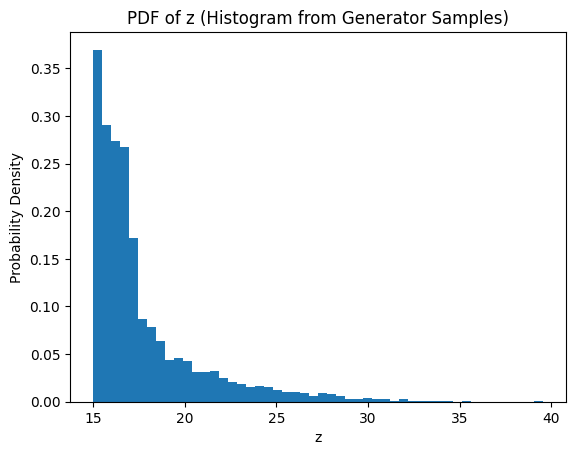

In [7]:
# Step 3
from numpy.random import randn

n_samples = 5000
error = randn(n_samples, 1)

z_f = generator.predict(error, verbose=0)

import matplotlib.pyplot as plt

plt.hist(z_f, bins=50, density=True)
plt.xlabel("z")
plt.ylabel("Probability Density")
plt.title("PDF of z (Histogram from Generator Samples)")
plt.show()


### **SUBMISSION INFO**
## **Transformation Parameters**

The transformation applied to the NO₂ values is defined as:<br>
z = x + a_r \sin(b_r x)<br>

For roll number (r=102317003):

( a_r = 0.5 \times (r \bmod 7) = 2.0 )<br>
( b_r = 0.5 \times ((r \bmod 5) + 1) = 2.0 )<br>

These parameters introduce a non-linear sinusoidal variation to the original NO₂ values, resulting in a transformed variable with a more complex distribution.

## **GAN Architecture Description**

A simple one-dimensional Generative Adversarial Network (GAN) is used to learn the distribution of the transformed variable (z).

* **Generator**

  * Input: random noise sampled from a standard normal distribution ( N(0,1) )
  * Structure: one hidden dense layer with ReLU activation followed by a linear output layer
  * Output: generated samples ( z_f )

* **Discriminator**

  * Input: real samples ( z ) and generated samples ( z_f )
  * Structure: one hidden dense layer with ReLU activation followed by a sigmoid output layer
  * Output: probability indicating whether the input sample is real or fake

The generator and discriminator are trained alternately in an adversarial manner, allowing the generator to gradually learn the underlying distribution of ( z ).

## **Observations**

### **Mode Coverage**

The generator is able to capture the main modes of the transformed data distribution. The generated samples span a wide range of ( z ) values similar to the real data, indicating that the model does not suffer from severe mode collapse.

### **Training Stability**

The training process remains stable over the training epochs. Although minor fluctuations are observed, which are typical in GAN training, the model does not diverge and continues to produce increasingly realistic samples.

### **Quality of Generated Distribution**

The probability density function estimated from the generator samples closely follows the overall shape of the real data distribution. While small differences are present, the generated distribution successfully captures the main trends and density patterns of the transformed variable.